## Objetivo
**Estimar** el tiempo característico de decaimiento de un muon

In [13]:
# Código para extraer el último valor de cada línea (tiempos) del archivo de datos

# Leer el archivo de datos
file_path = "MuonDecayData_Events_2025-09-05_12-10-06.txt"

# Lista para almacenar los tiempos
times = []

# Leer el archivo línea por línea
with open(file_path, 'r') as file:
    for line in file:
        # Eliminar espacios en blanco y dividir por comas
        parts = line.strip().split(', ')
        
        # El último elemento es el tiempo
        if len(parts) >= 3:  # Verificar que la línea tenga el formato esperado
            time_value = int(parts[-1])  # Convertir a entero
            times.append(time_value)

### Cálculo con tiempo promedio

In [ ]:
import numpy as np

# Convertir la lista de tiempos a un array de numpy
times_array = np.array(times)

# Dividir los tiempos por 10^8
times_scaled = times_array / (10**2)

# Calcular la media y la desviación estándar
mean_time = np.mean(times_scaled)
N = len(times_scaled)  # Número total de mediciones
standard_error = np.std(times_scaled) / np.sqrt(N) # Error estandar de la media

print(f"Número total de eventos: {N}")
print(f"Media: {mean_time:.6f}")
print(f"Error estándar de la media: {standard_error:.9f}")

print(f"\nResultado final:")
print(f"Tiempo característico = {mean_time:.6f} ± {standard_error:.6f}")

# Calcular el error relativo (porcentaje)
relative_error = (standard_error / mean_time) * 100
print(f"Error relativo: {relative_error:.2f}%")

Número total de eventos: 2290
Media: 2.210428
Error estándar de la media: 0.046170868

Resultado final:
Tiempo característico = 2.210428 ± 0.046171
En notación científica: (2.210e+00 ± 4.617e-02)
Error relativo: 2.09%


In [12]:
print(f"Error porcentual: {(abs(mean_time - 2)/2):.2f}%")

Error porcentual: 0.11%


### Histograma de datos

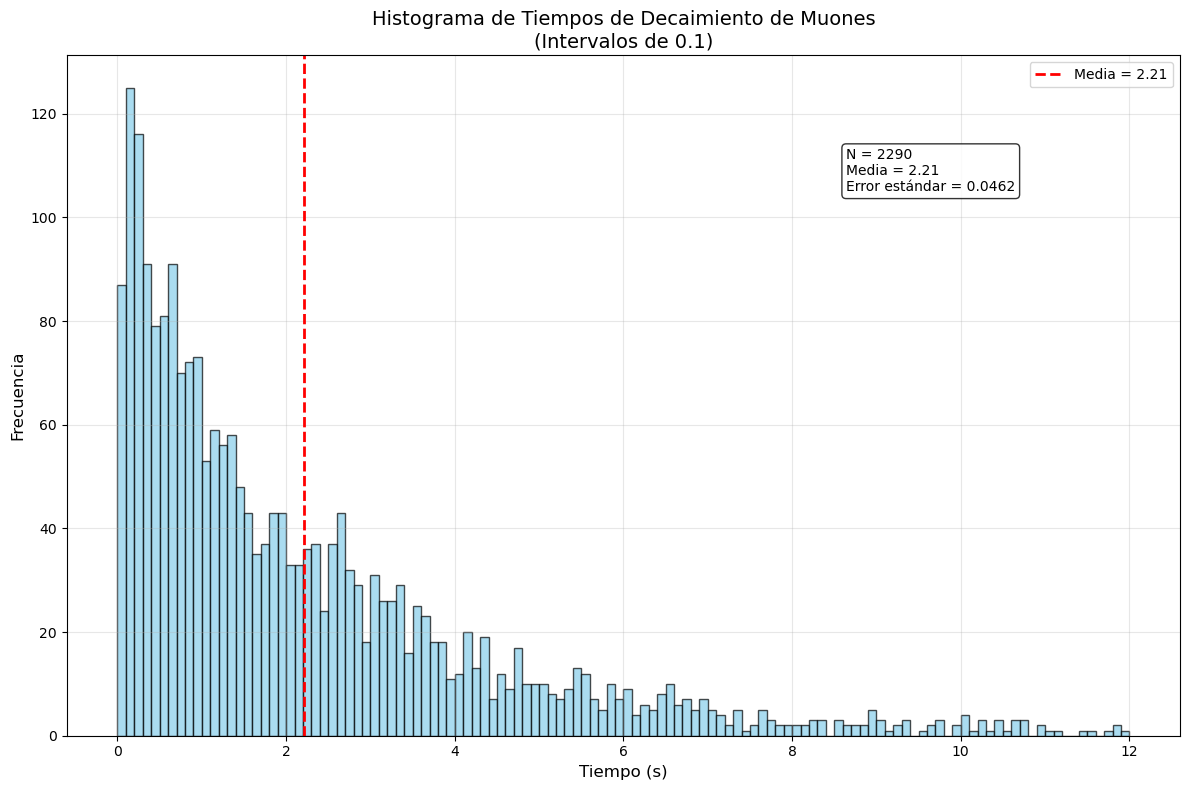

Información del histograma:
Número de bins: 120
Rango de datos: 0.03 - 11.95
Ancho de cada intervalo: 50
Bin con mayor frecuencia: 0.100 - 0.200 (frecuencia: 125)


In [18]:
import matplotlib.pyplot as plt

# Crear histograma agrupando los datos por intervalos de 50
plt.figure(figsize=(12, 8))

# Usar los tiempos escalados (divididos por 10^2)
# Crear bins con intervalos de 0.1
bins = np.arange(0, max(times_scaled) + 0.1, 0.1)

# Crear el histograma
n, bins_edges, patches = plt.hist(times_scaled, bins=bins, alpha=0.7, color='skyblue', edgecolor='black')

# Personalizar el gráfico
plt.xlabel('Tiempo (s)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Histograma de Tiempos de Decaimiento de Muones\n(Intervalos de 0.1)', fontsize=14)
plt.grid(True, alpha=0.3)

# Añadir línea vertical en la media
plt.axvline(mean_time, color='red', linestyle='--', linewidth=2, 
            label=f'Media = {mean_time:.2f}')

# Añadir estadísticas en el gráfico
plt.text(0.7, 0.8, f'N = {N}\nMedia = {mean_time:.2f}\nError estándar = {standard_error:.4f}', 
         transform=plt.gca().transAxes, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
         fontsize=10)

plt.legend()
plt.tight_layout()
plt.show()

# Mostrar información adicional sobre los bins
print(f"Información del histograma:")
print(f"Número de bins: {len(bins_edges)-1}")
print(f"Rango de datos: {min(times_scaled):.2f} - {max(times_scaled):.2f}")
print(f"Ancho de cada intervalo: 50")
print(f"Bin con mayor frecuencia: {bins_edges[np.argmax(n)]:.3f} - {bins_edges[np.argmax(n)+1]:.3f} (frecuencia: {int(max(n))})")

### Regresión no lineal por mínimos cuadrados

Resultados del ajuste exponencial:
N0 (valor inicial) = 108.47 ± 2.37
τ (constante de tiempo) = 2.0590 ± 0.0636
Vida media (τ) = 2.0590 ± 0.0636 segundos


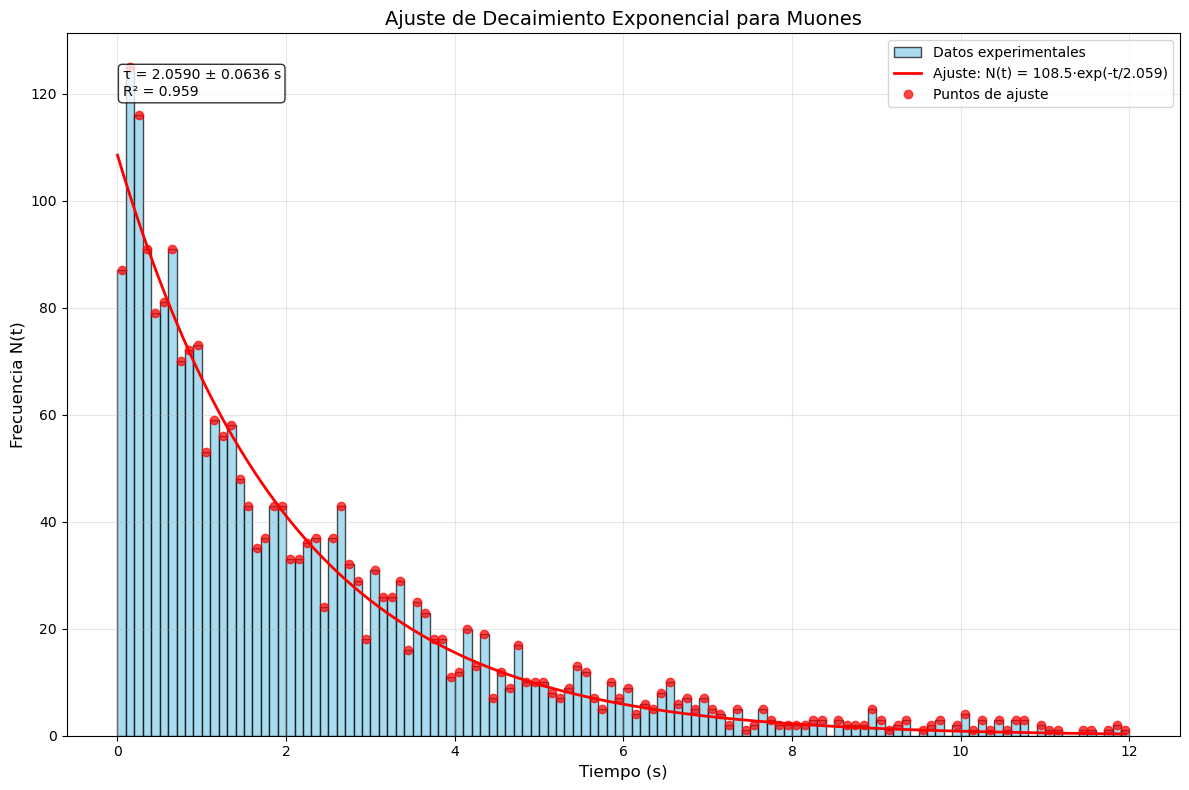


Calidad del ajuste:
R² = 0.9590
Error cuadrático medio = 5.31


In [ ]:
# from scipy.optimize import curve_fit

# # Definir la función de decaimiento exponencial
# def exponential_decay(t, N0, tau):
#     """
#     Función de decaimiento exponencial: N(t) = N0 * exp(-t/tau)
#     t: tiempo
#     N0: valor inicial
#     tau: constante de tiempo (vida media)
#     """
#     return N0 * np.exp(-t / tau)

# # Preparar los datos para el ajuste
# # Usar las frecuencias del histograma como N(t)
# frequencies = n  # frecuencias de cada bin

# # Calcular los puntos medios de cada intervalo (t = 0.05, 0.15, 0.25, ...)
# bin_centers = (bins_edges[:-1] + bins_edges[1:]) / 2

# # Filtrar datos para evitar valores cero en el logaritmo
# mask = frequencies > 0
# t_data = bin_centers[mask]
# N_data = frequencies[mask]

# # Realizar el ajuste con valor inicial N0 = 125
# initial_guess = [125, 2.0]  # [N0, tau]

# try:
#     # Ajuste de curva
#     popt, pcov = curve_fit(exponential_decay, t_data, N_data, p0=initial_guess)
#     N0_fit, tau_fit = popt
    
#     # Calcular errores
#     errors = np.sqrt(np.diag(pcov))
#     N0_error, tau_error = errors
    
#     print(f"Resultados del ajuste exponencial:")
#     print(f"N0 (valor inicial) = {N0_fit:.2f} ± {N0_error:.2f}")
#     print(f"τ (constante de tiempo) = {tau_fit:.4f} ± {tau_error:.4f}")
#     print(f"Vida media (τ) = {tau_fit:.4f} ± {tau_error:.4f} segundos")
    
#     # Crear gráfico con histograma y ajuste
#     plt.figure(figsize=(12, 8))
    
#     # Histograma
#     plt.hist(times_scaled, bins=bins, alpha=0.7, color='skyblue', 
#              edgecolor='black', label='Datos experimentales')
    
#     # Curva ajustada
#     t_fit = np.linspace(0, max(times_scaled), 1000)
#     N_fit = exponential_decay(t_fit, N0_fit, tau_fit)
#     plt.plot(t_fit, N_fit, 'r-', linewidth=2, 
#              label=f'Ajuste: N(t) = {N0_fit:.1f}·exp(-t/{tau_fit:.3f})')
    
#     # Puntos usados para el ajuste
#     plt.plot(t_data, N_data, 'ro', markersize=6, alpha=0.7, 
#              label='Puntos de ajuste')
    
#     # Personalizar gráfico
#     plt.xlabel('Tiempo (s)', fontsize=12)
#     plt.ylabel('Frecuencia N(t)', fontsize=12)
#     plt.title('Ajuste de Decaimiento Exponencial para Muones', fontsize=14)
#     plt.grid(True, alpha=0.3)
#     plt.legend()
    
#     # Añadir texto con resultados
#     plt.text(0.05, 0.95, 
#              f'τ = {tau_fit:.4f} ± {tau_error:.4f} s\nR² = {1 - np.sum((N_data - exponential_decay(t_data, *popt))**2) / np.sum((N_data - np.mean(N_data))**2):.3f}',
#              transform=plt.gca().transAxes, 
#              bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
#              fontsize=10, verticalalignment='top')
    
#     plt.tight_layout()
#     plt.show()
    
#     # Calcular R²
#     y_pred = exponential_decay(t_data, *popt)
#     ss_res = np.sum((N_data - y_pred) ** 2)
#     ss_tot = np.sum((N_data - np.mean(N_data)) ** 2)
#     r_squared = 1 - (ss_res / ss_tot)
    
#     print(f"\nCalidad del ajuste:")
#     print(f"R² = {r_squared:.4f}")
#     print(f"Error cuadrático medio = {np.sqrt(np.mean((N_data - y_pred)**2)):.2f}")

# except Exception as e:
#     print(f"Error en el ajuste: {e}")
#     print("Verificar que los datos sean apropiados para el ajuste exponencial")